<h2 style="color:#FFD866; border-left:5px solid #FFD866; padding-left:12px;">
1. Drive 연결
</h2>

In [22]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<h2 style="color:#FFD866; border-left:5px solid #FFD866; padding-left:12px;">
2. 데이터셋을 Colab 내부로 복사
</h2>

In [23]:
import shutil
from pathlib import Path

DRIVE_ZIP = Path(
    "/content/drive/MyDrive/AI_Project/wardy/ml/src/data/hazard_objects_v1.zip"
)

LOCAL_ZIP = Path("/content/object_dataset.zip")
EXTRACT_DIR = Path("/content/object_dataset_extracted")
LOCAL_DATASET = Path("/content/hazard_objects_v1")

if not DRIVE_ZIP.is_file():
    raise FileNotFoundError(f"ZIP 파일을 찾을 수 없습니다:\n{DRIVE_ZIP}")

print("ZIP 복사 중...")
shutil.copy2(DRIVE_ZIP, LOCAL_ZIP)

print("압축 해제 중...")
shutil.unpack_archive(LOCAL_ZIP, EXTRACT_DIR)

# ZIP 내부에서 실제 데이터셋 폴더 검색
dataset_roots = [
    yaml_path.parent
    for yaml_path in EXTRACT_DIR.rglob("data.yaml")
    if (yaml_path.parent / "images").is_dir()
    and (yaml_path.parent / "labels").is_dir()
]

if not dataset_roots:
    raise FileNotFoundError(
        "ZIP 안에서 images, labels, data.yaml 구조를 찾지 못했습니다."
    )

SOURCE_DATASET = dataset_roots[0]

# 학습에 사용할 고정 경로로 복사
shutil.copytree(
    SOURCE_DATASET,
    LOCAL_DATASET,
    dirs_exist_ok=True,
)

print("데이터셋 준비 완료:", LOCAL_DATASET)
print("data.yaml:", LOCAL_DATASET / "data.yaml")

ZIP 복사 중...
압축 해제 중...
데이터셋 준비 완료: /content/hazard_objects_v1
data.yaml: /content/hazard_objects_v1/data.yaml


<h2 style="color:#FFD866; border-left:5px solid #FFD866; padding-left:12px;">
3. Colab용 data.yaml 작성
</h2>

In [24]:
from pathlib import Path

yaml_text = """
path: /content/hazard_objects_v1
train: images/train
val: images/val
test: images/test

names:
  0: scissors
  1: knife
  2: cutter
  3: syringe
"""

Path("/content/hazard_objects_v1/data.yaml").write_text(
    yaml_text.strip() + "\n",
    encoding="utf-8"
)

print(Path("/content/hazard_objects_v1/data.yaml").read_text())

path: /content/hazard_objects_v1
train: images/train
val: images/val
test: images/test

names:
  0: scissors
  1: knife
  2: cutter
  3: syringe



<h2 style="color:#FFD866; border-left:5px solid #FFD866; padding-left:12px;">
4. 이미지와 라벨 개수 확인
</h2>

In [25]:
from pathlib import Path

root = Path("/content/hazard_objects_v1")

for split in ["train", "val", "test"]:
    image_count = len([
        p for p in (root / "images" / split).iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    ])
    label_count = len(list((root / "labels" / split).glob("*.txt")))

    print(f"{split:5s} 이미지: {image_count}, 라벨: {label_count}")

train 이미지: 4623, 라벨: 4623
val   이미지: 579, 라벨: 579
test  이미지: 569, 라벨: 569


<h2 style="color:#FFD866; border-left:5px solid #FFD866; padding-left:12px;">
5. Ultralytics 설치
</h2>

In [26]:
%pip install -q ultralytics==8.4.115

<h2 style="color:#FFD866; border-left:5px solid #FFD866; padding-left:12px;">
6. 100 epoch 본학습
</h2>

In [ ]:
from pathlib import Path
from ultralytics import YOLO
import shutil

SAVE_DIR = Path(
    "/content/drive/MyDrive/AI_Project/wardy/ml/src/export"
)

RUN_NAME = "hazard_objects_v1_full_v1"
RUN_DIR = SAVE_DIR / RUN_NAME
BEST_MODEL = RUN_DIR / "weights" / "best.pt"
LAST_MODEL = RUN_DIR / "weights" / "last.pt"

if RUN_DIR.exists():
    shutil.rmtree(RUN_DIR)

model = YOLO("yolo11n.pt")

results = model.train(
    data="/content/hazard_objects_v1/data.yaml",
    epochs=100,
    patience=20,
    imgsz=640,
    batch=8,
    device=0,
    workers=2,
    project=str(SAVE_DIR),
    name=RUN_NAME,
    exist_ok=True,
    resume=False,
    save_period=10,
    seed=42,
    plots=True,
)

print("학습 결과 폴더:", RUN_DIR)
print("best.pt:", BEST_MODEL)
print("last.pt:", LAST_MODEL)


Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/hazard_objects_v1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hazard_objects_v1_full_v

<h2 style="color:#FFD866; border-left:5px solid #FFD866; padding-left:12px;">
7. 본학습 결과 확인
</h2>

<h3 style="color:#FFD866; border-left:3px solid #FFD866; padding-left:8px;">
1. 결과 폴더 지정
</h3>

In [28]:
print("결과 폴더:", RUN_DIR)
print("폴더 존재:", RUN_DIR.exists())


결과 폴더: /content/drive/MyDrive/AI_Project/wardy/ml/src/export/hazard_objects_v1_full_v1
폴더 존재: True


<h3 style="color:#FFD866; border-left:3px solid #FFD866; padding-left:8px;">
2. 생성된 파일 확인
</h3>

In [29]:
for path in sorted(RUN_DIR.iterdir()):
    print(path.name)

BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
args.yaml
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
train_batch52020.jpg
train_batch52021.jpg
train_batch52022.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights


<h3 style="color:#FFD866; border-left:3px solid #FFD866; padding-left:8px;">
3. 학습 이미지와 정답 라벨 확인
</h3>

train_batch0.jpg


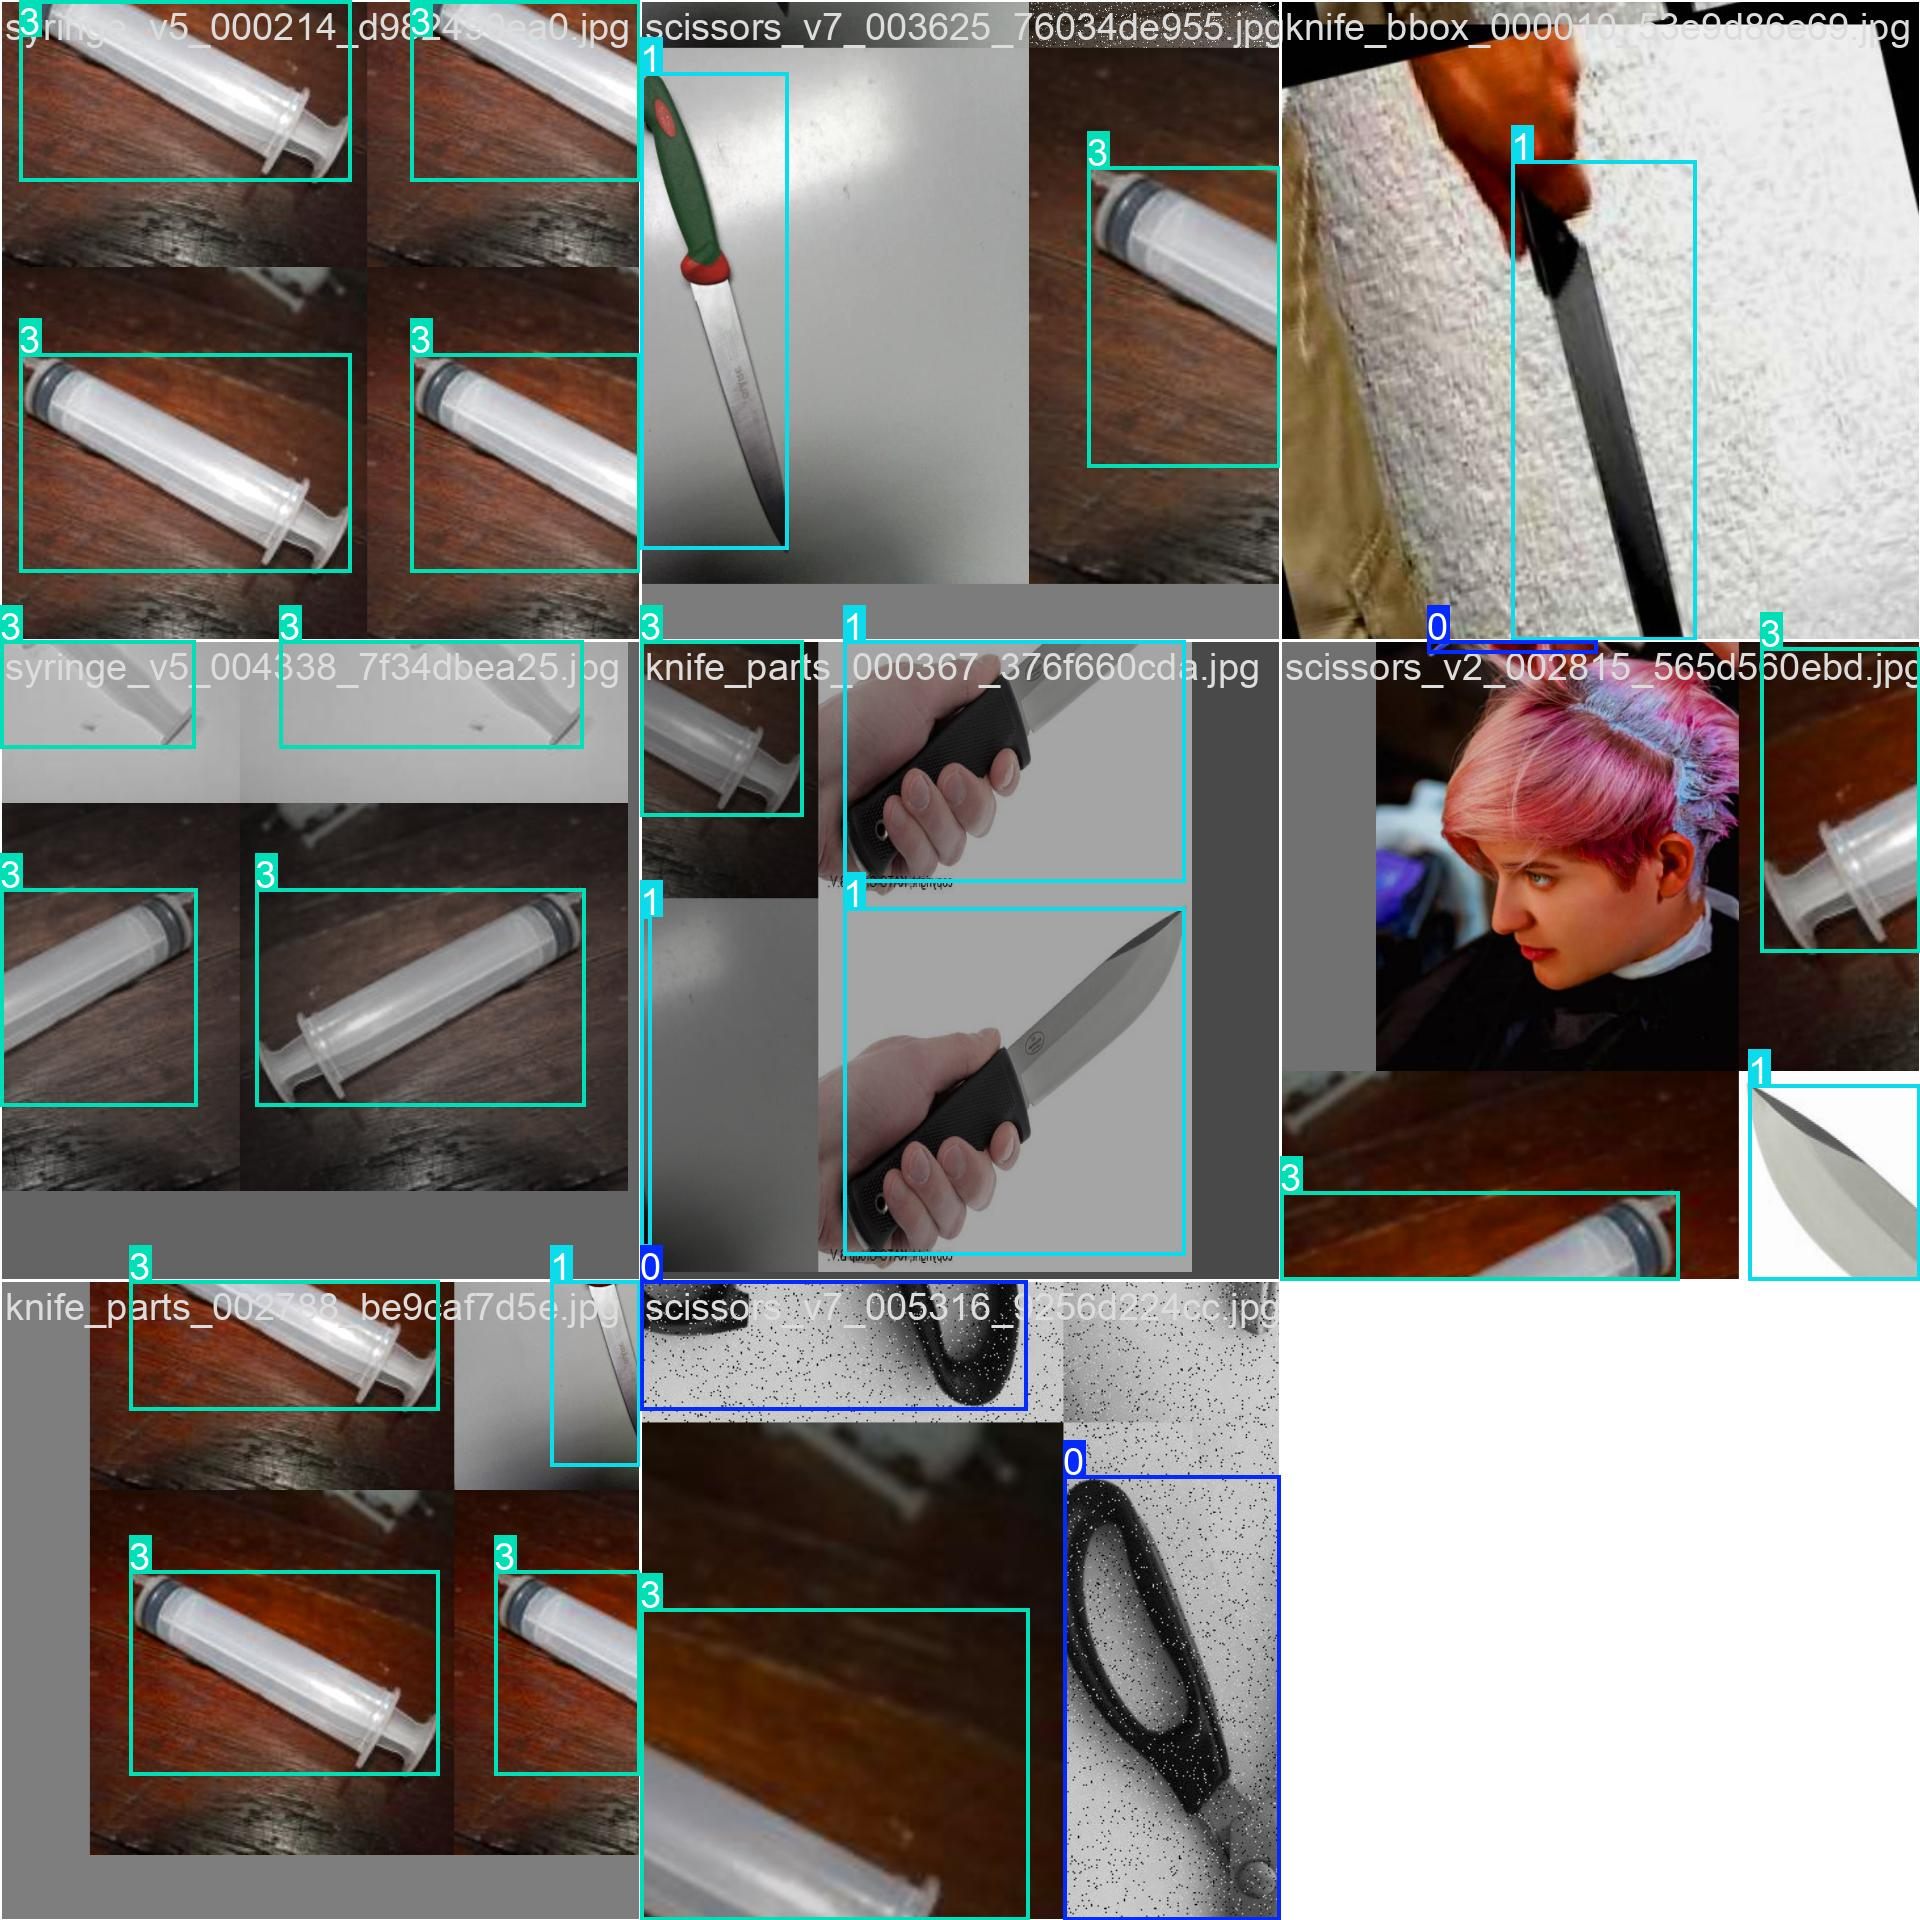

train_batch1.jpg


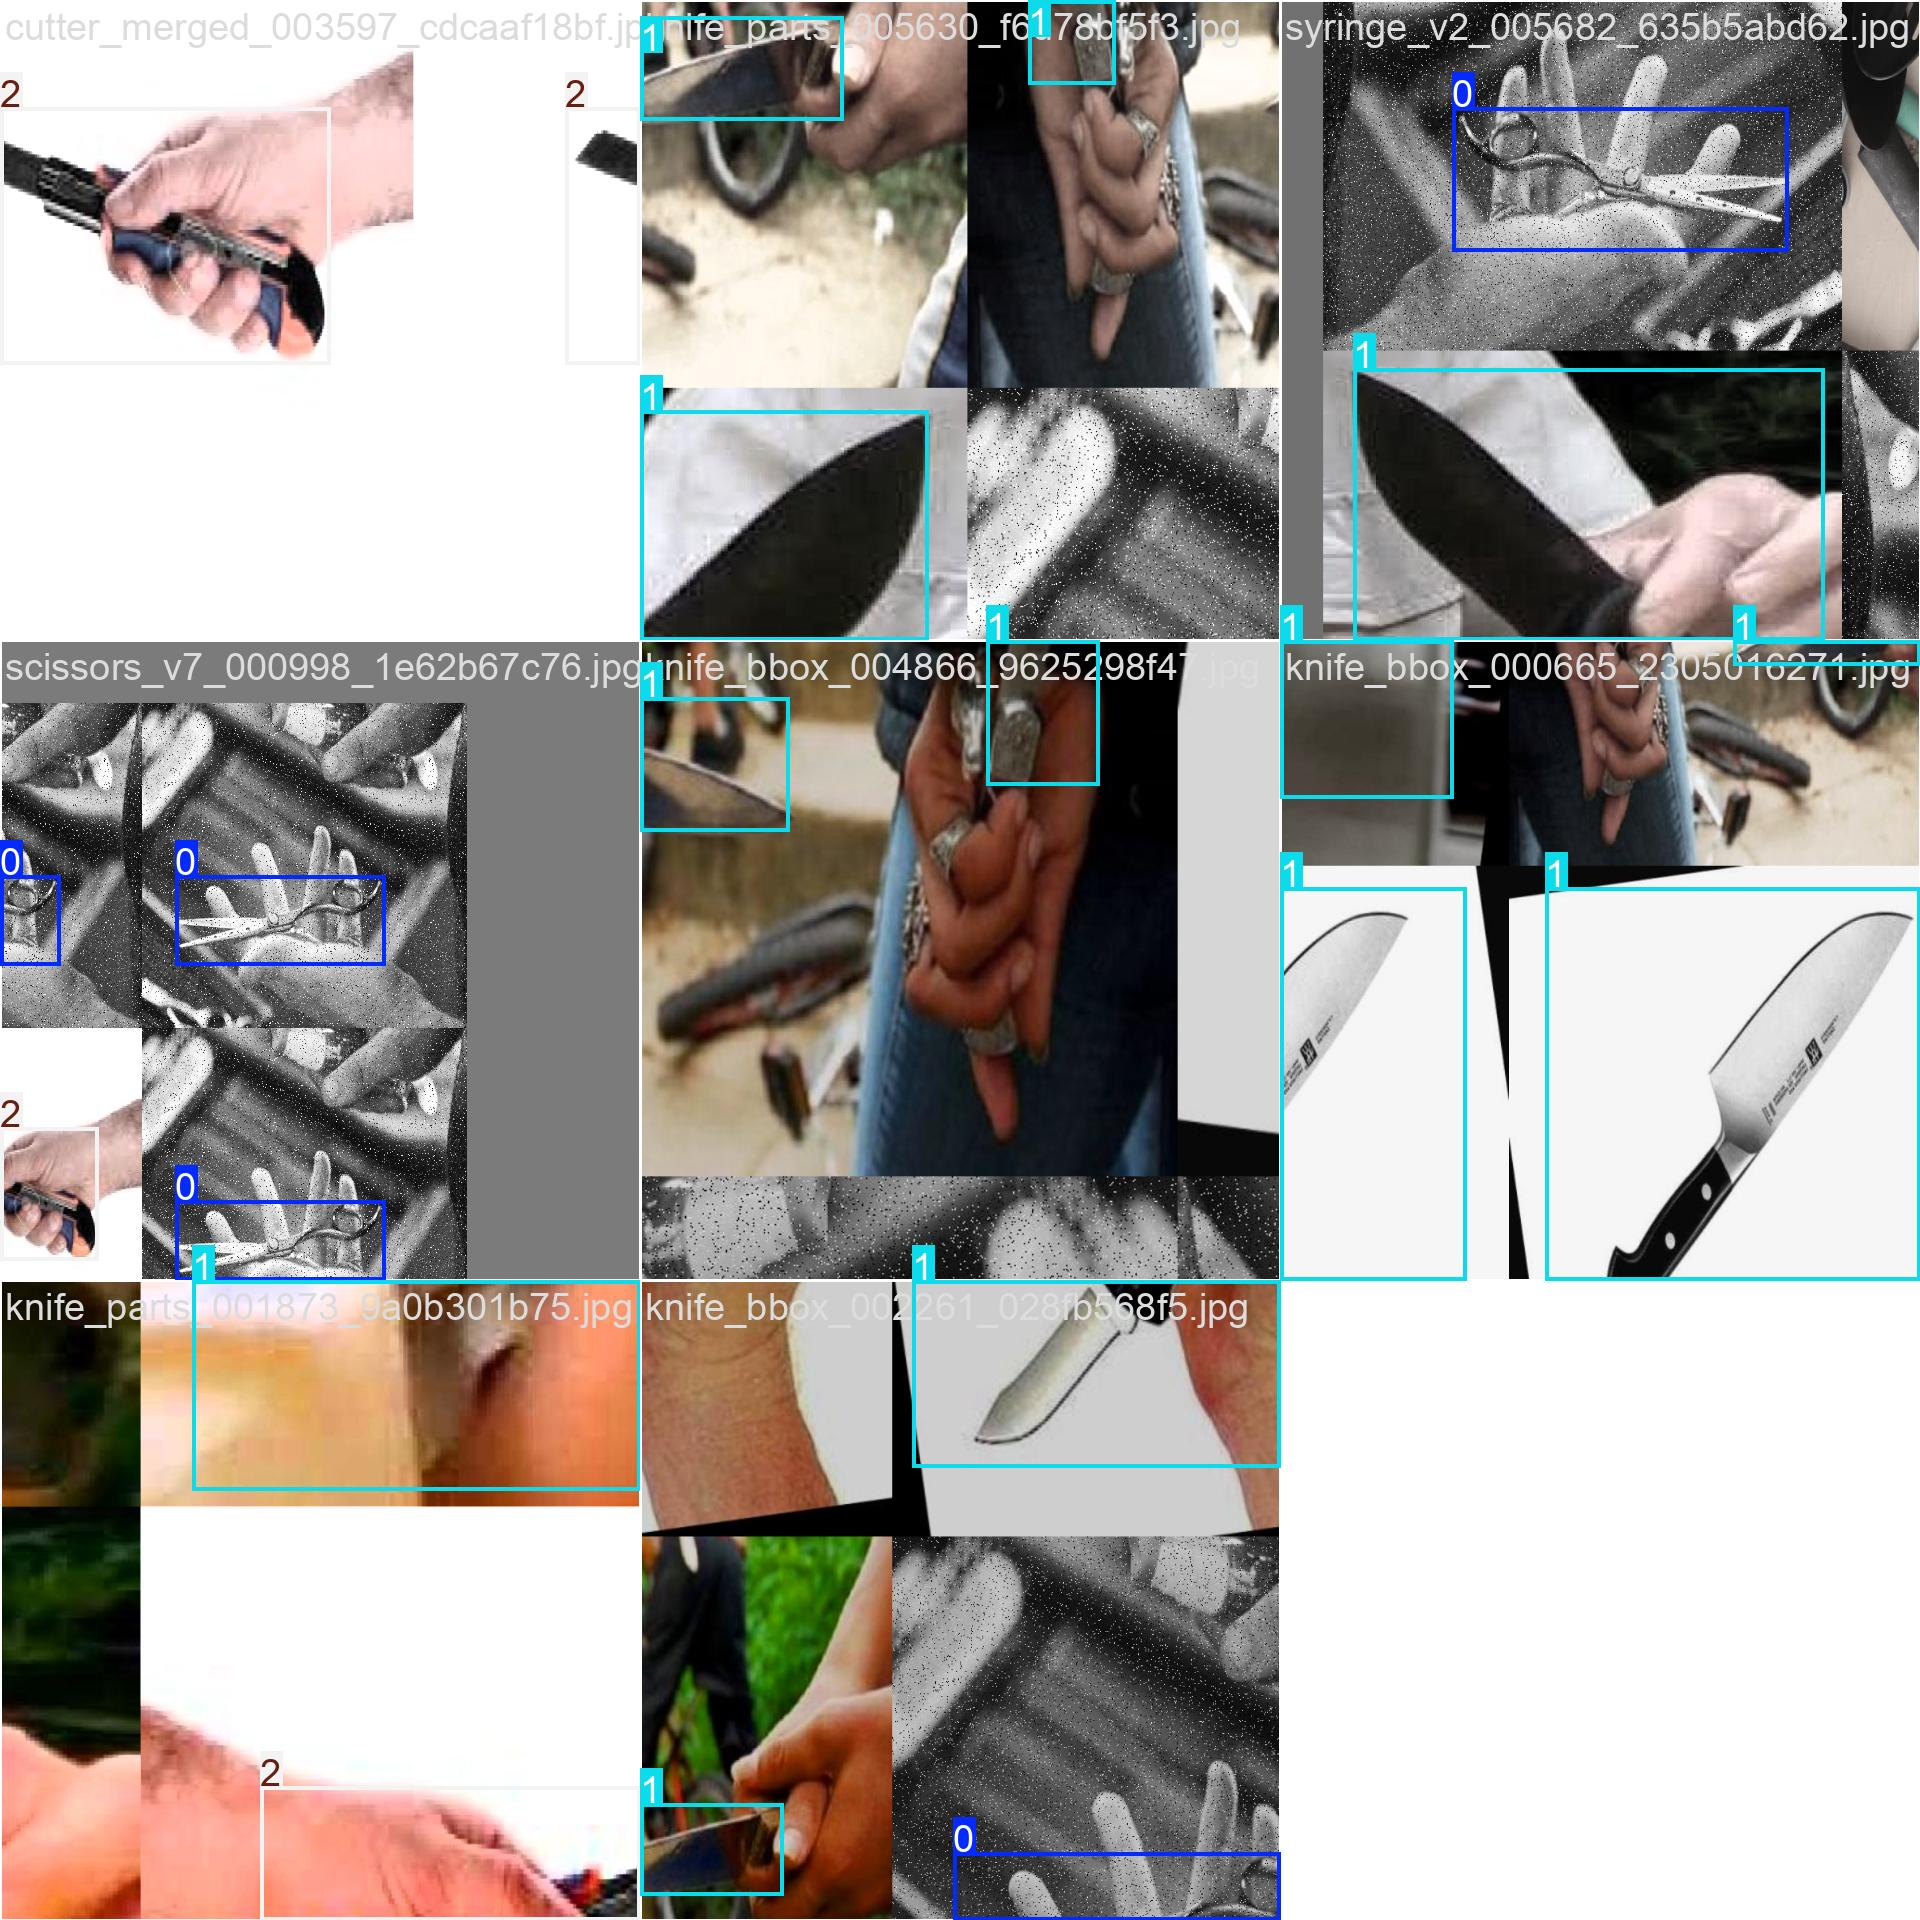

train_batch2.jpg


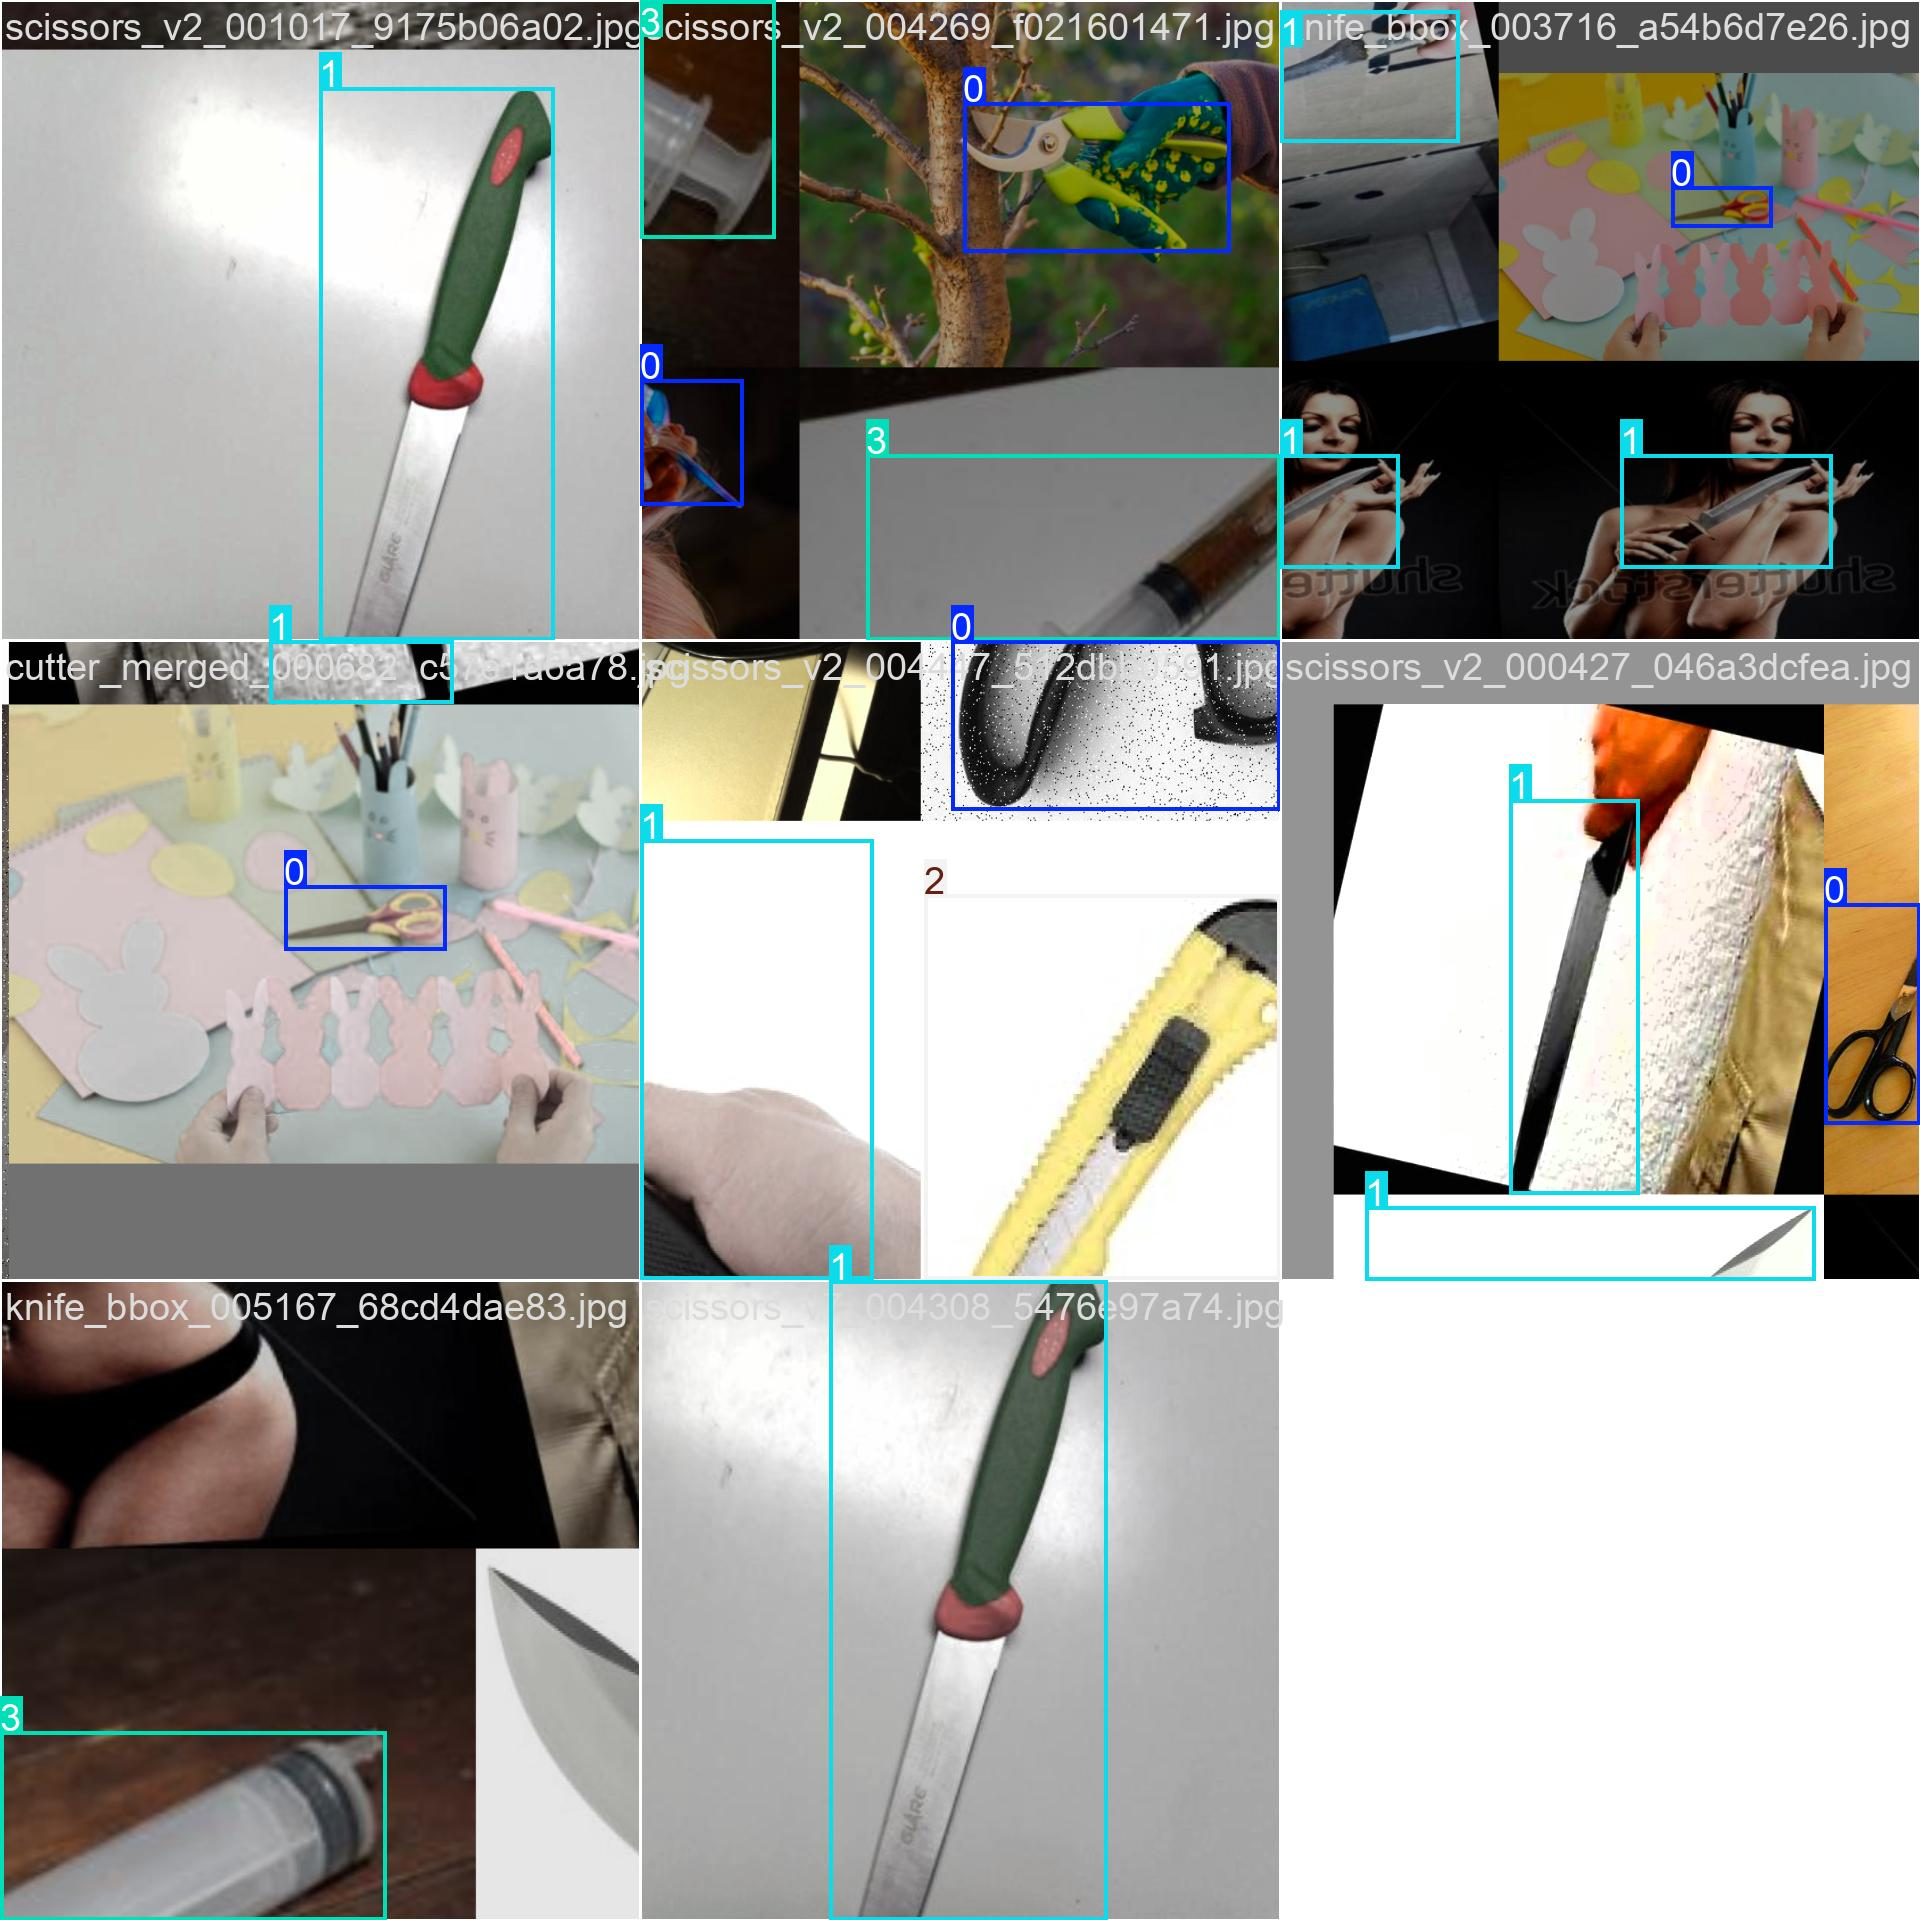

In [30]:
for filename in [
    "train_batch0.jpg",
    "train_batch1.jpg",
    "train_batch2.jpg",
]:
    path = RUN_DIR / filename

    if path.exists():
        print(filename)
        display(Image(filename=str(path), width=1000))

<h3 style="color:#FFD866; border-left:3px solid #FFD866; padding-left:8px;">
4. 검증 정답과 모델 예측 비교
</h3>

val_batch0_labels.jpg


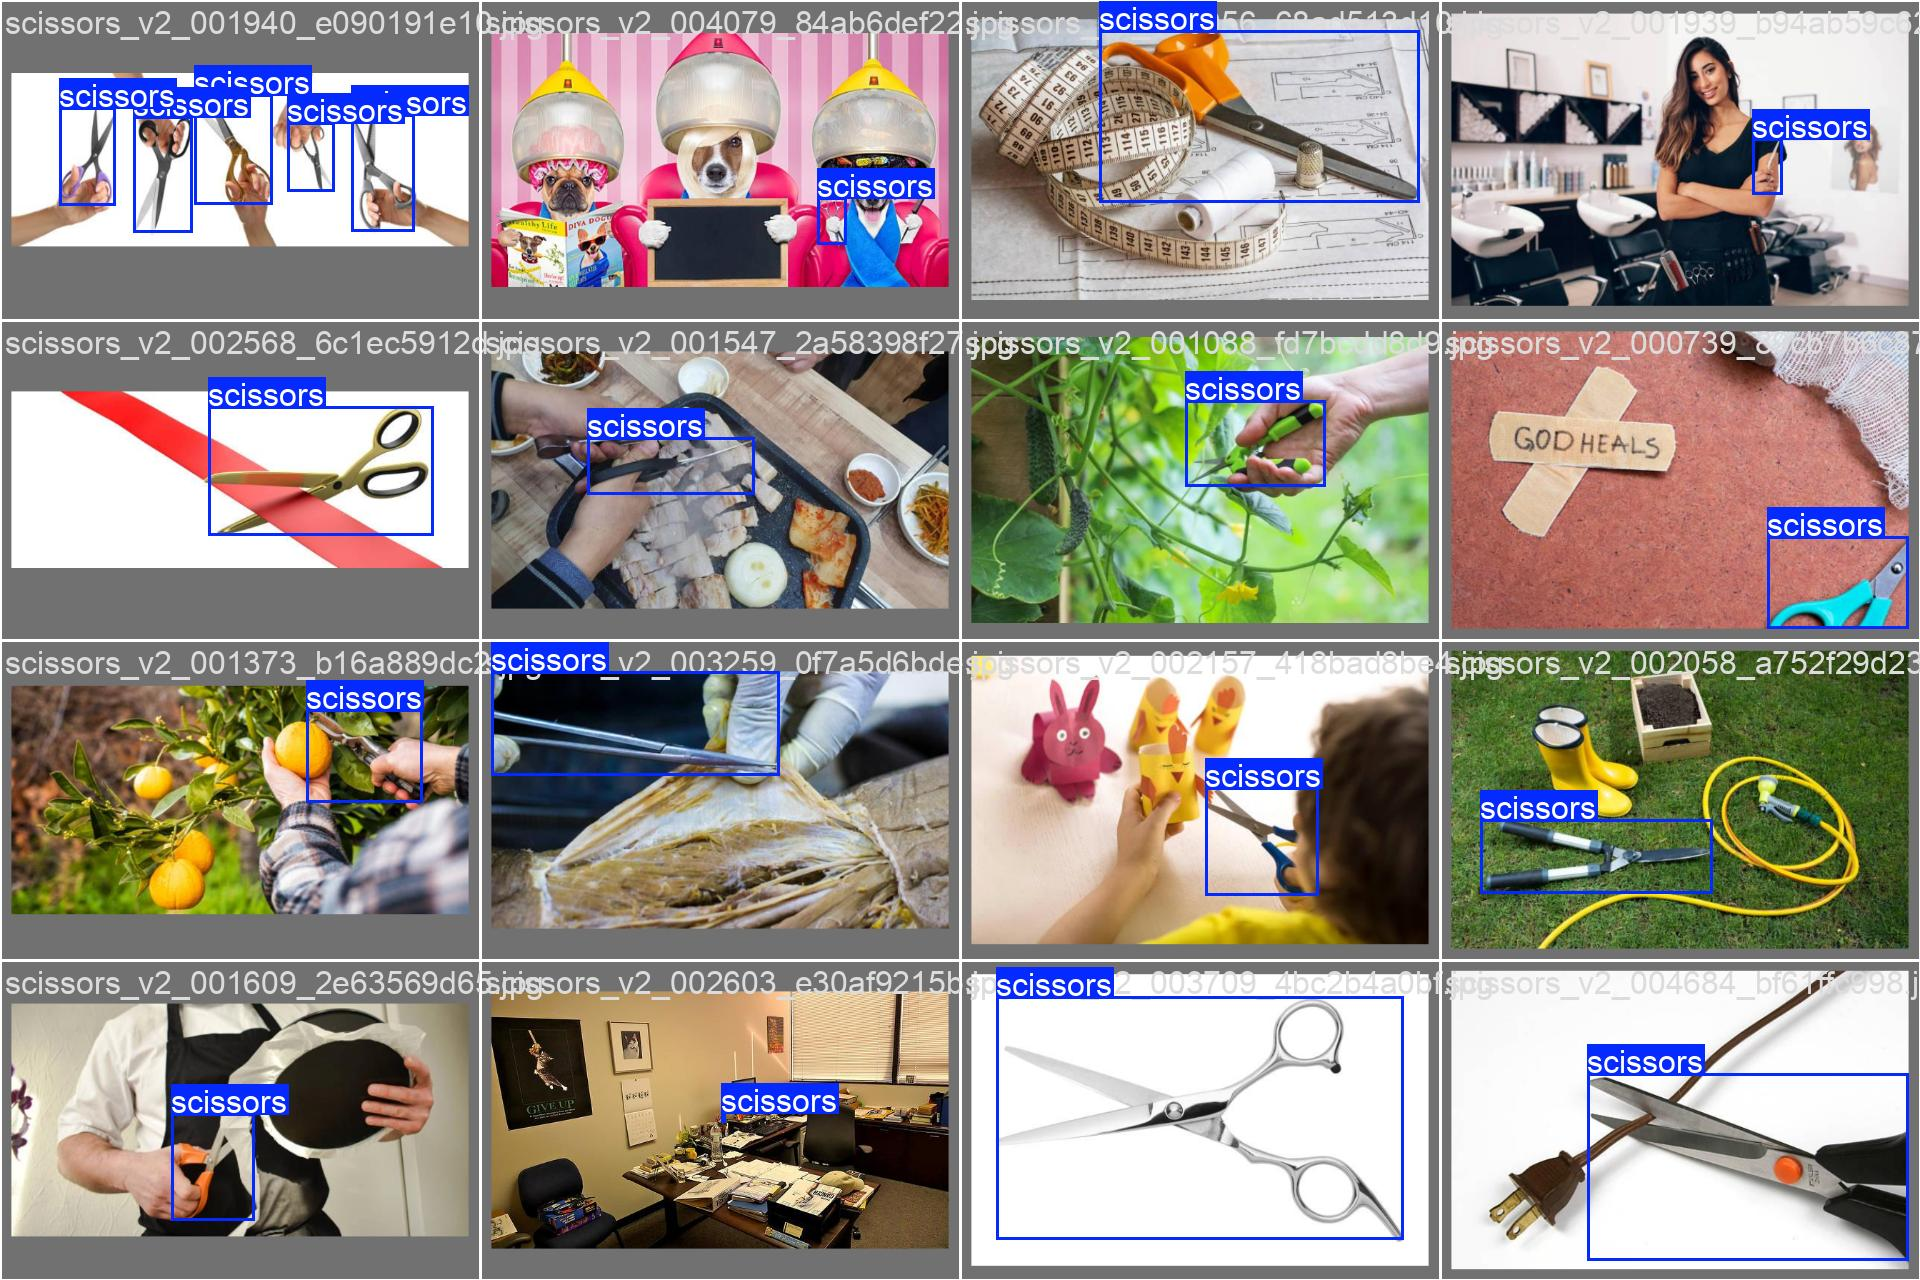

val_batch0_pred.jpg


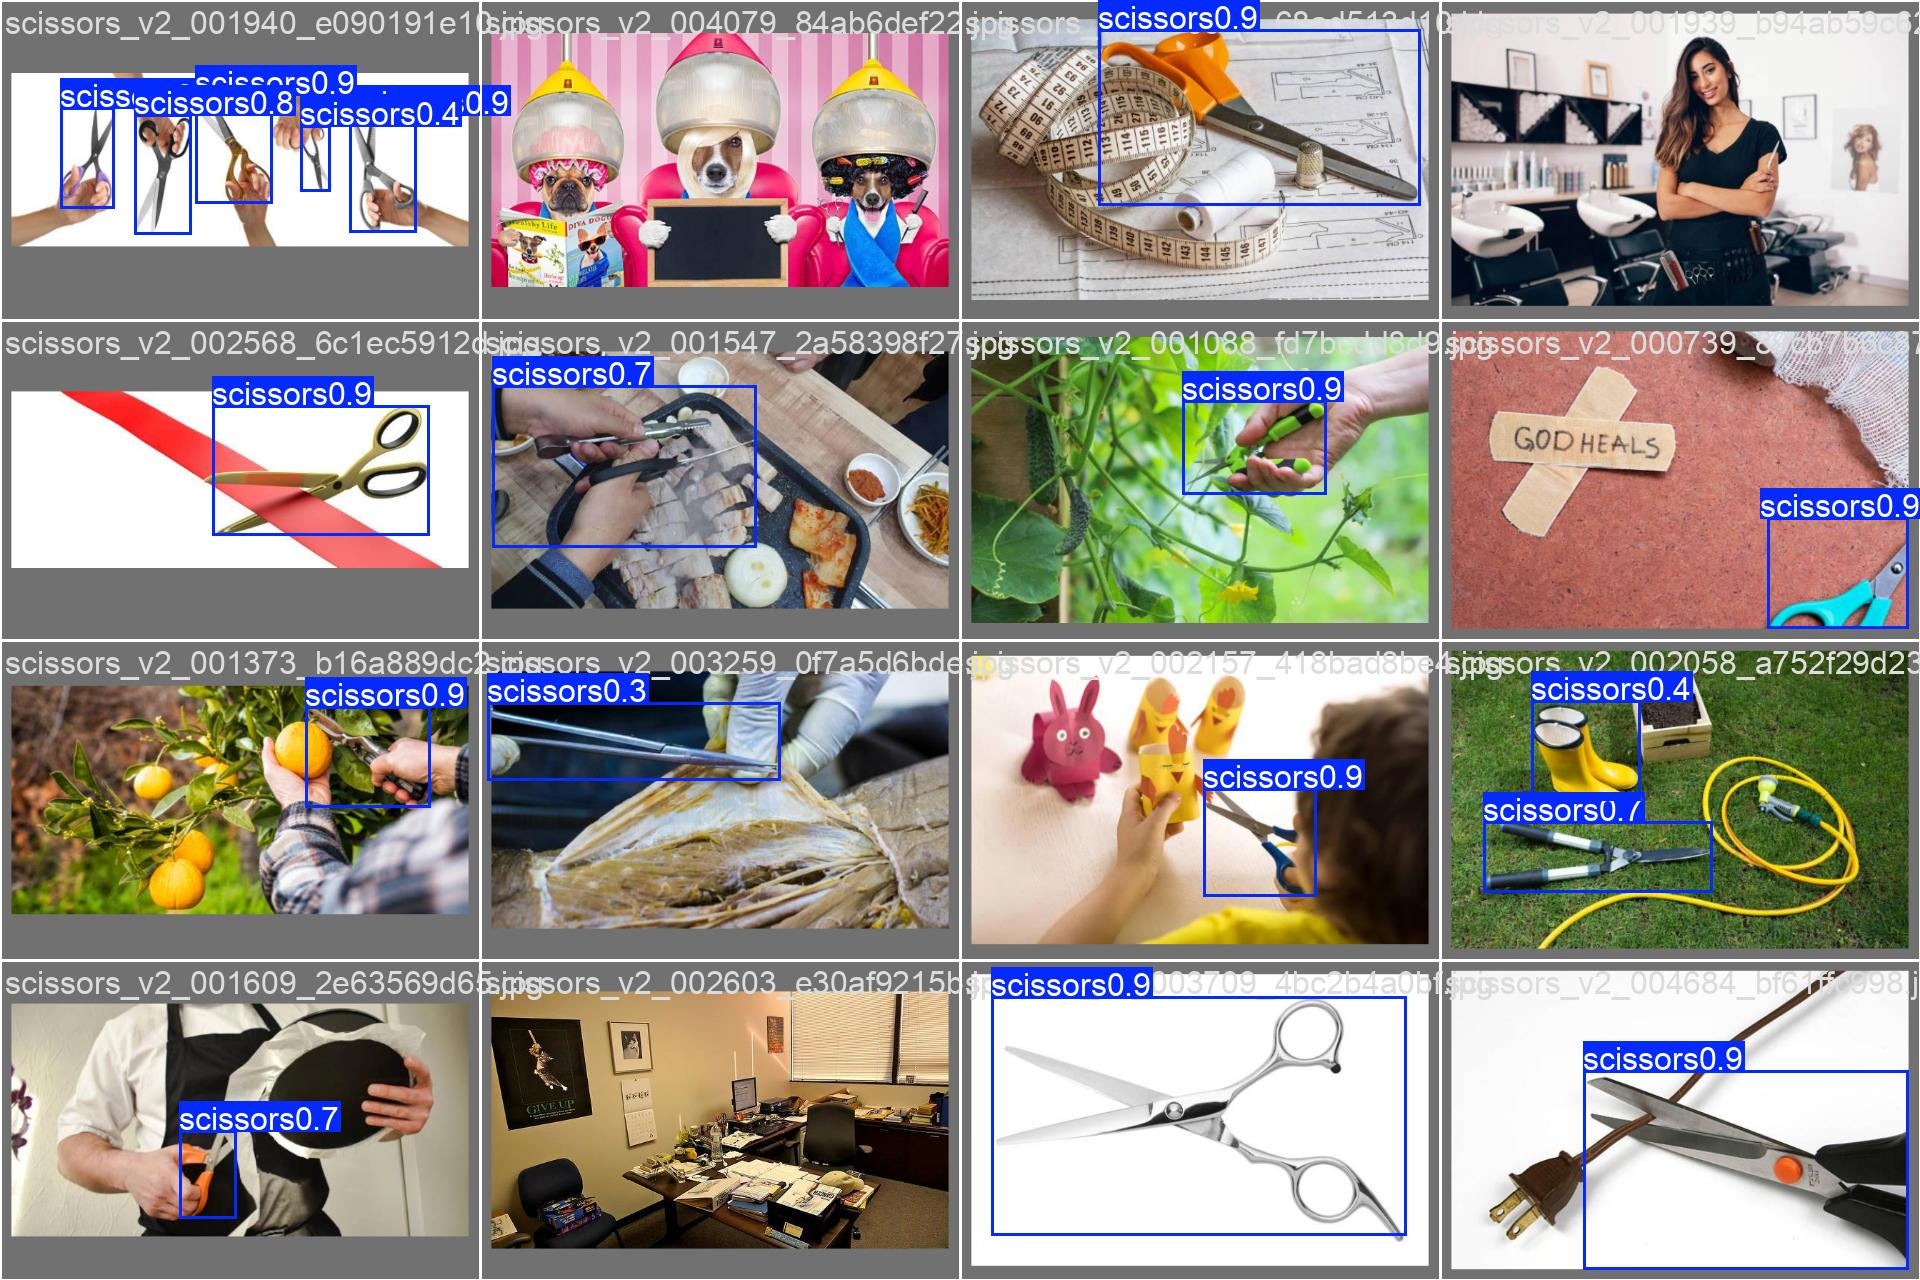

In [31]:
for filename in [
    "val_batch0_labels.jpg",
    "val_batch0_pred.jpg",
]:
    path = RUN_DIR / filename

    if path.exists():
        print(filename)
        display(Image(filename=str(path), width=1000))

<h3 style="color:#FFD866; border-left:3px solid #FFD866; padding-left:8px;">
5. 학습 그래프 확인
</h3>

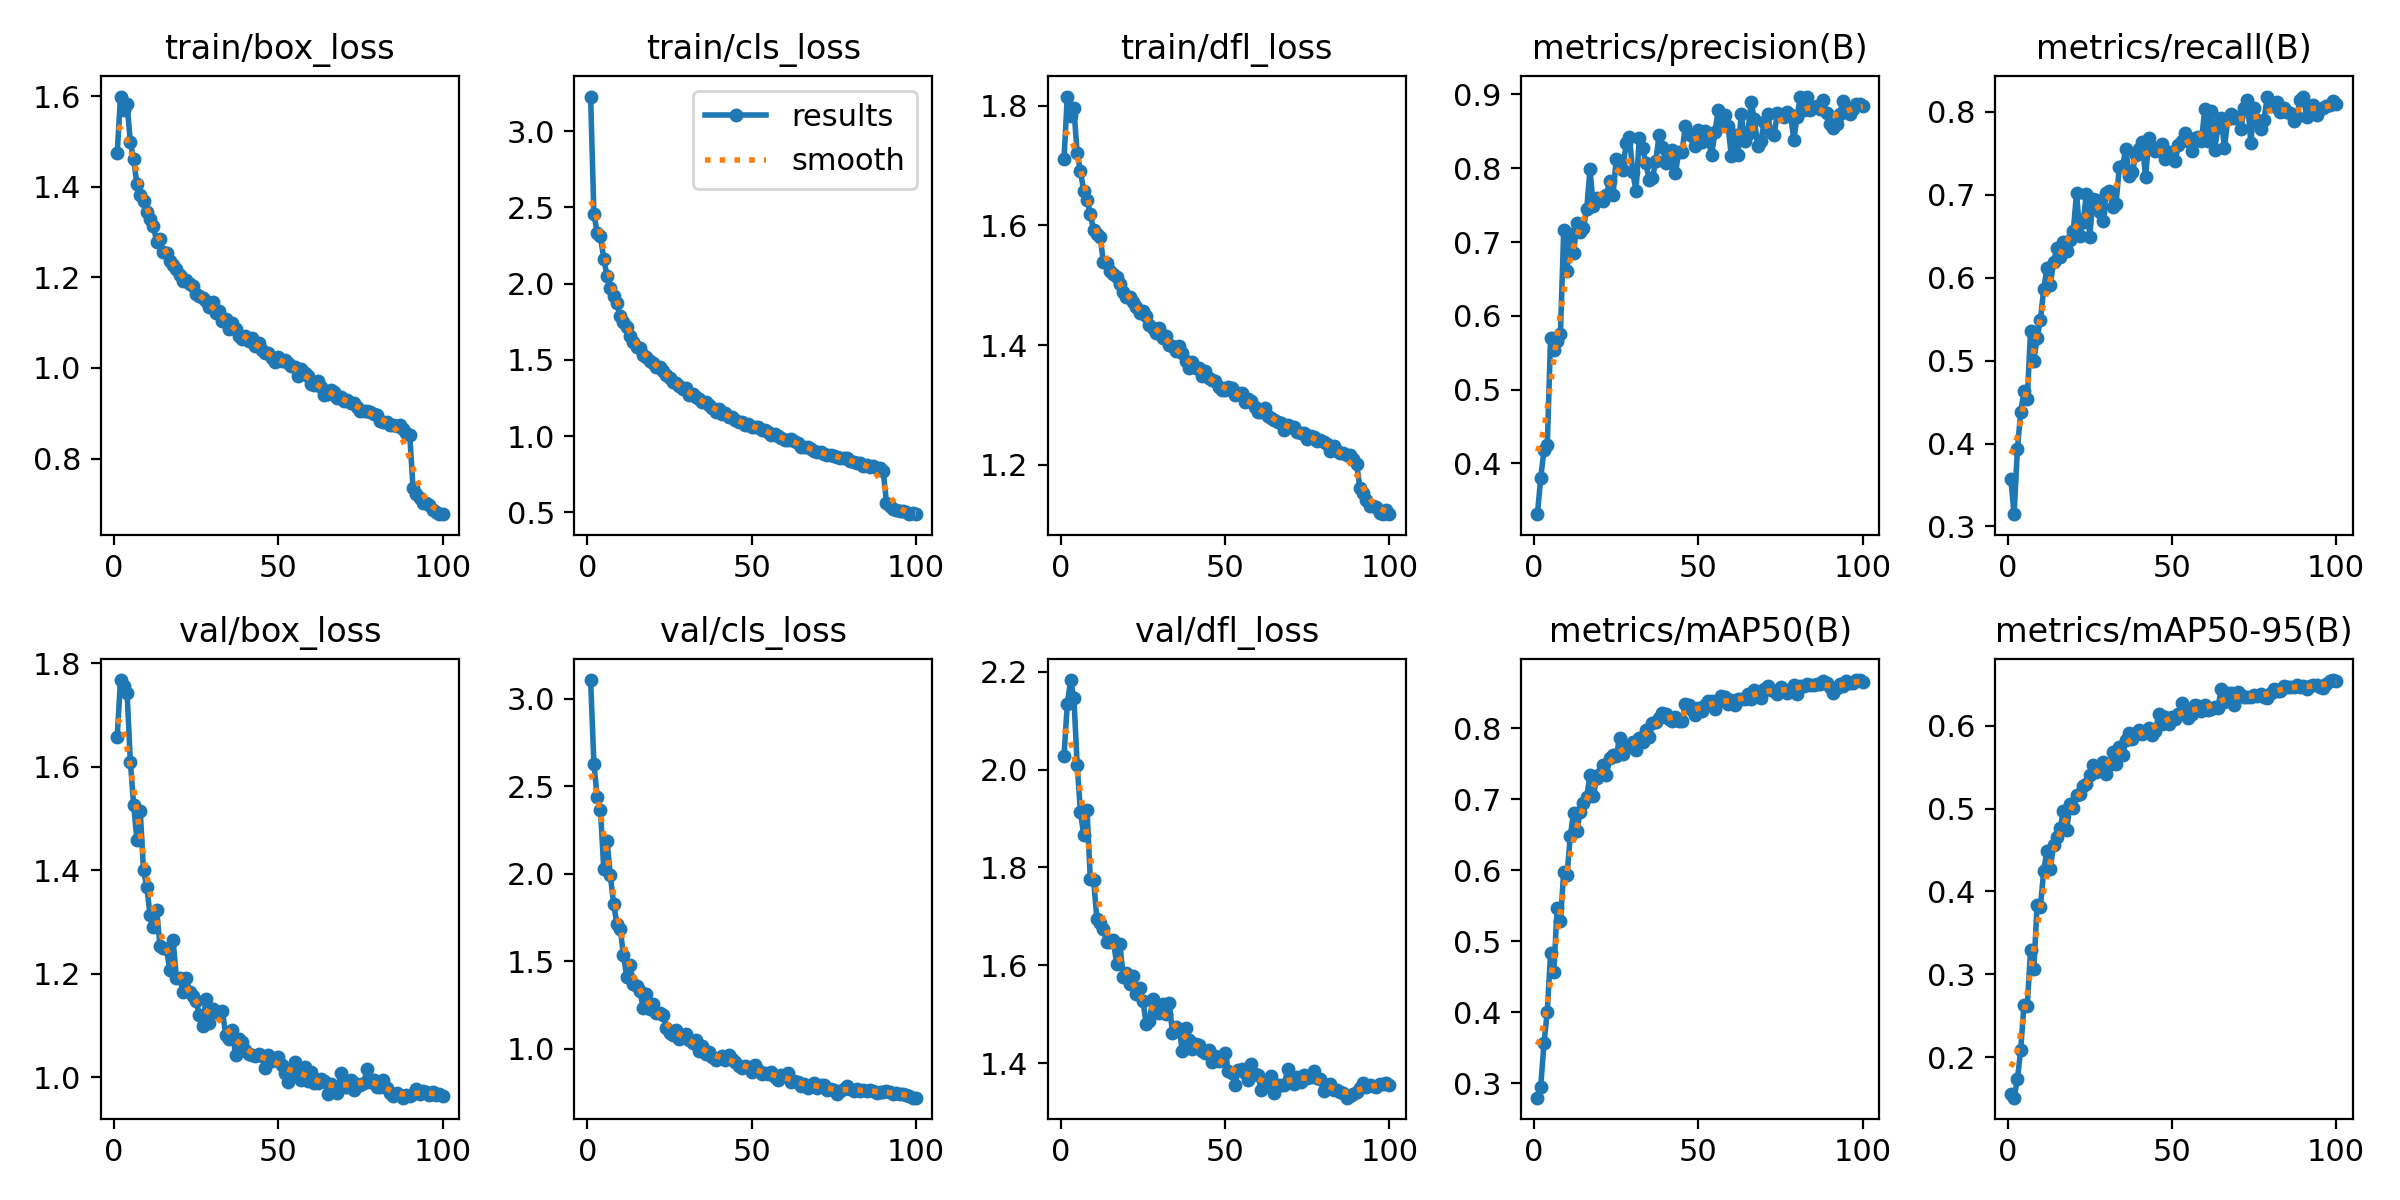

In [32]:
results_path = RUN_DIR / "results.png"

if results_path.exists():
    display(Image(filename=str(results_path), width=1100))

<h3 style="color:#FFD866; border-left:3px solid #FFD866; padding-left:8px;">
6. 혼동행렬 확인
</h3>

confusion_matrix.png


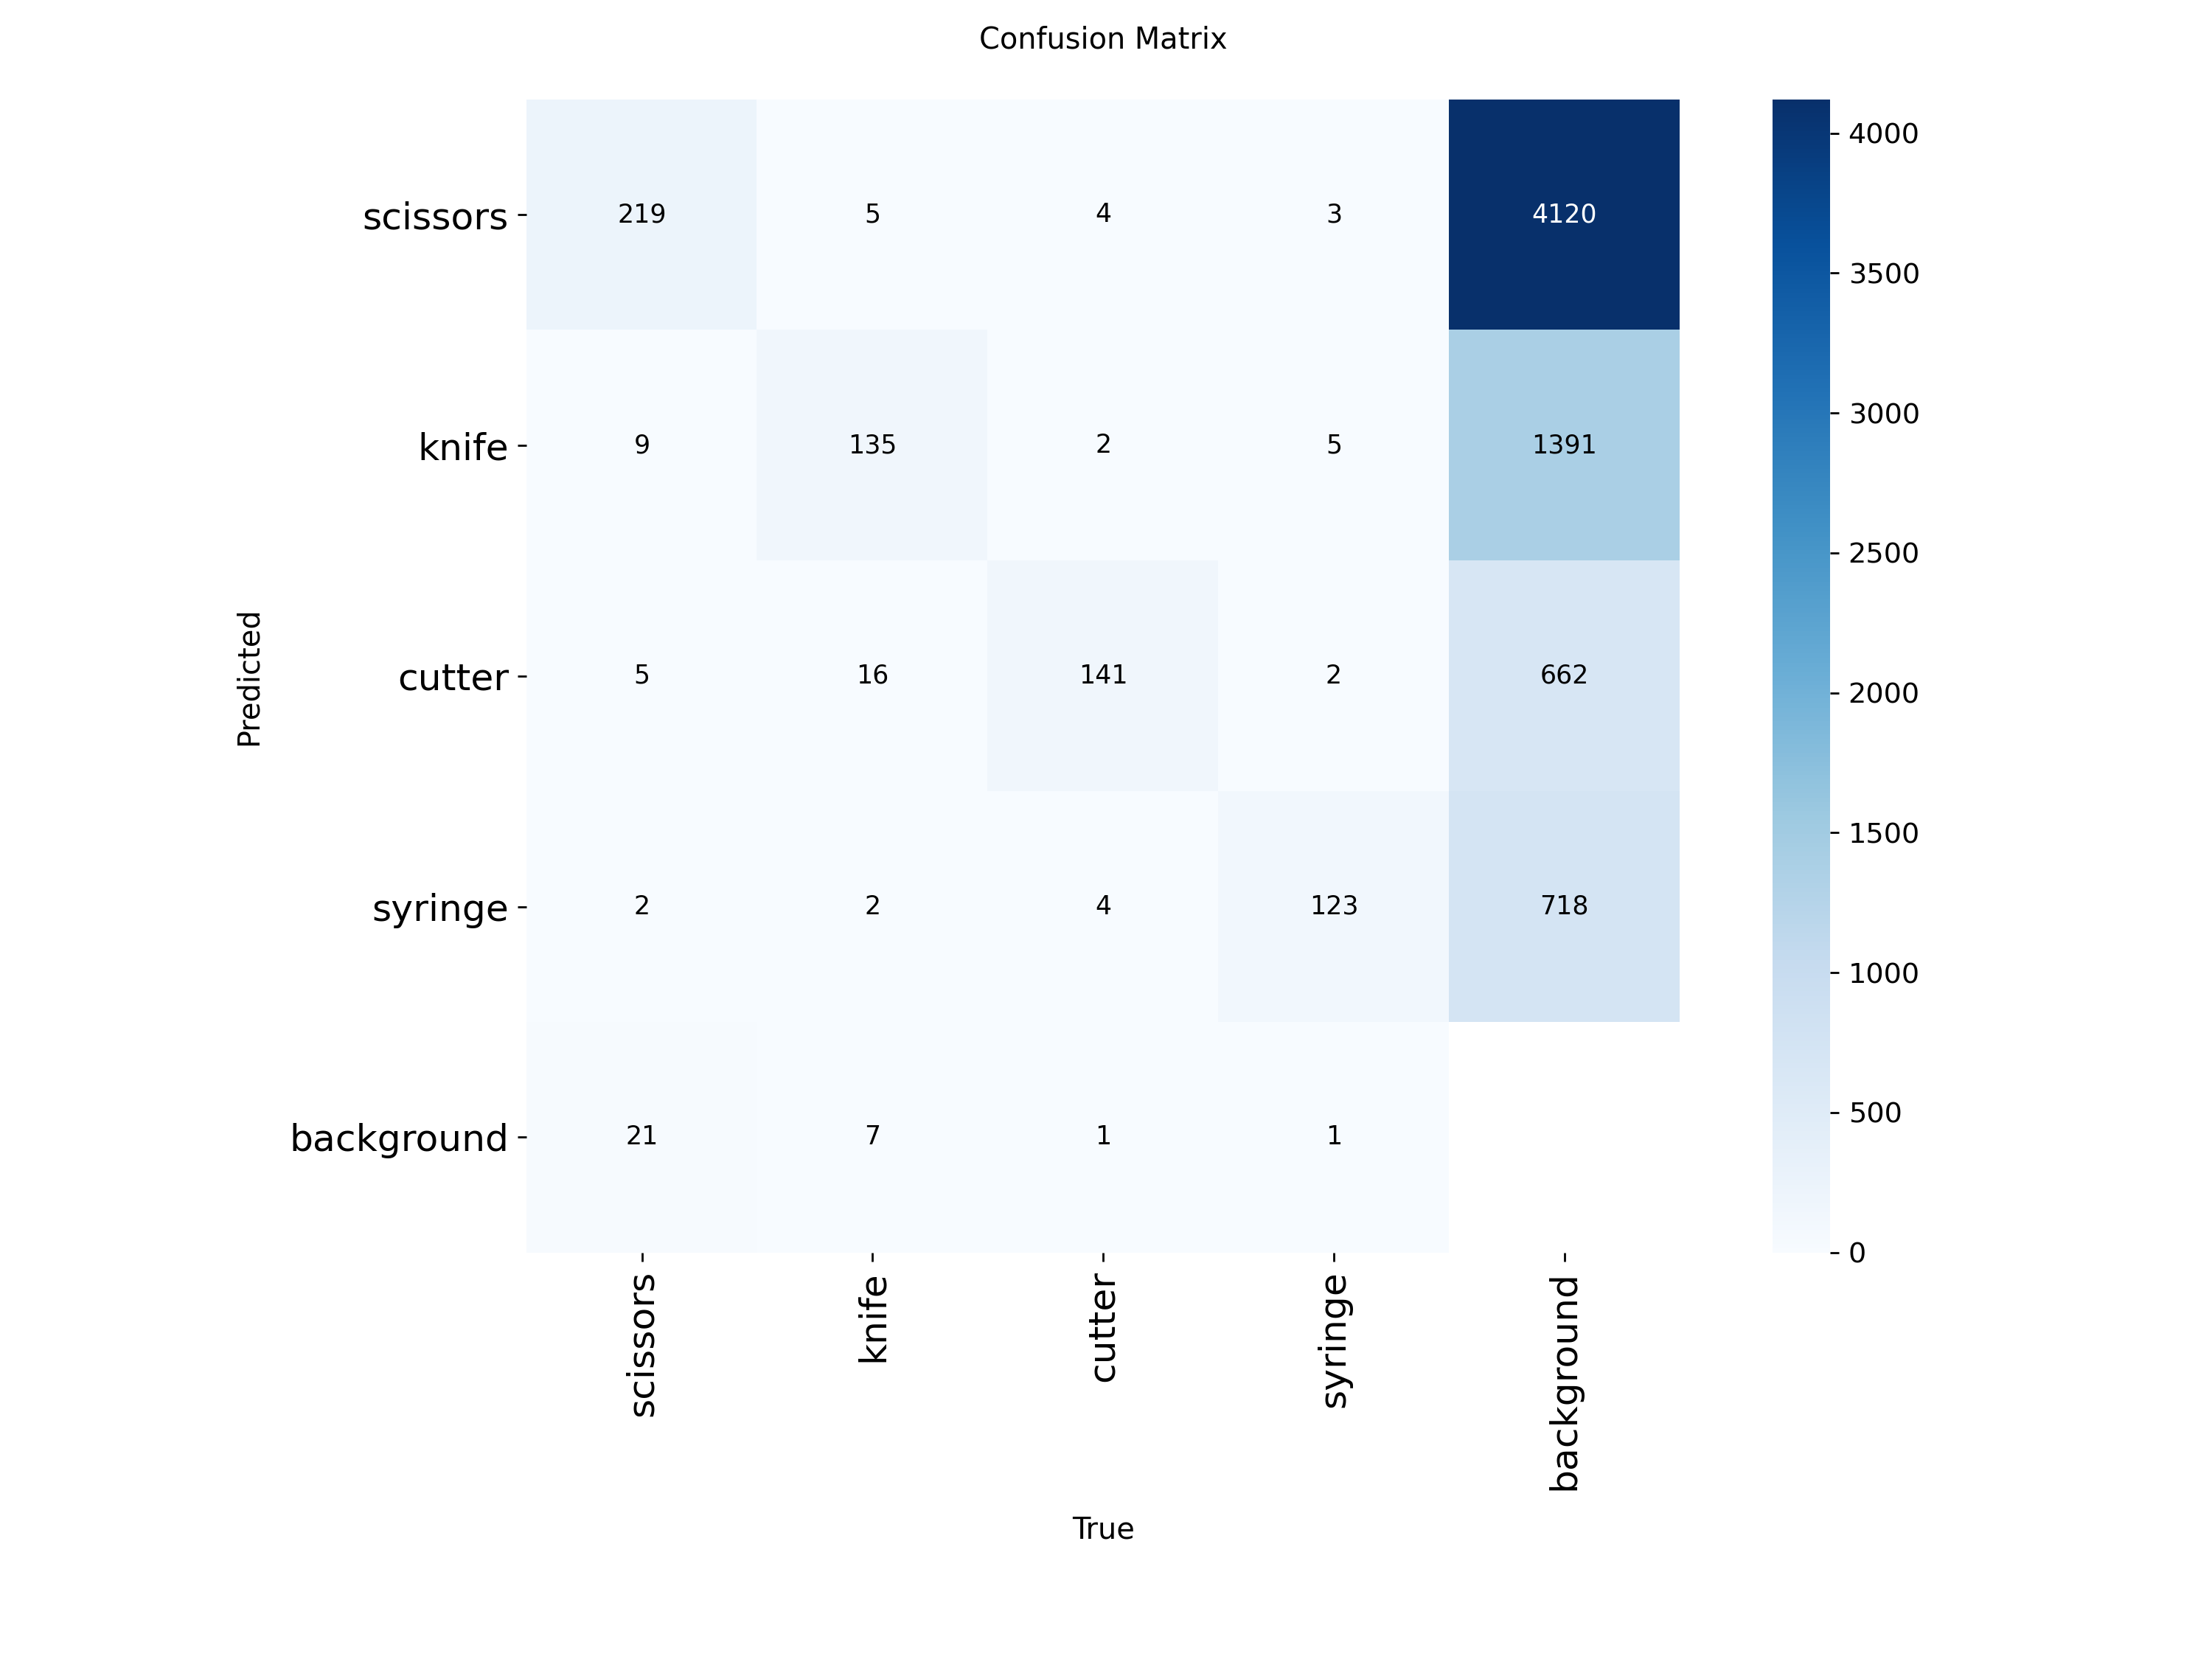

confusion_matrix_normalized.png


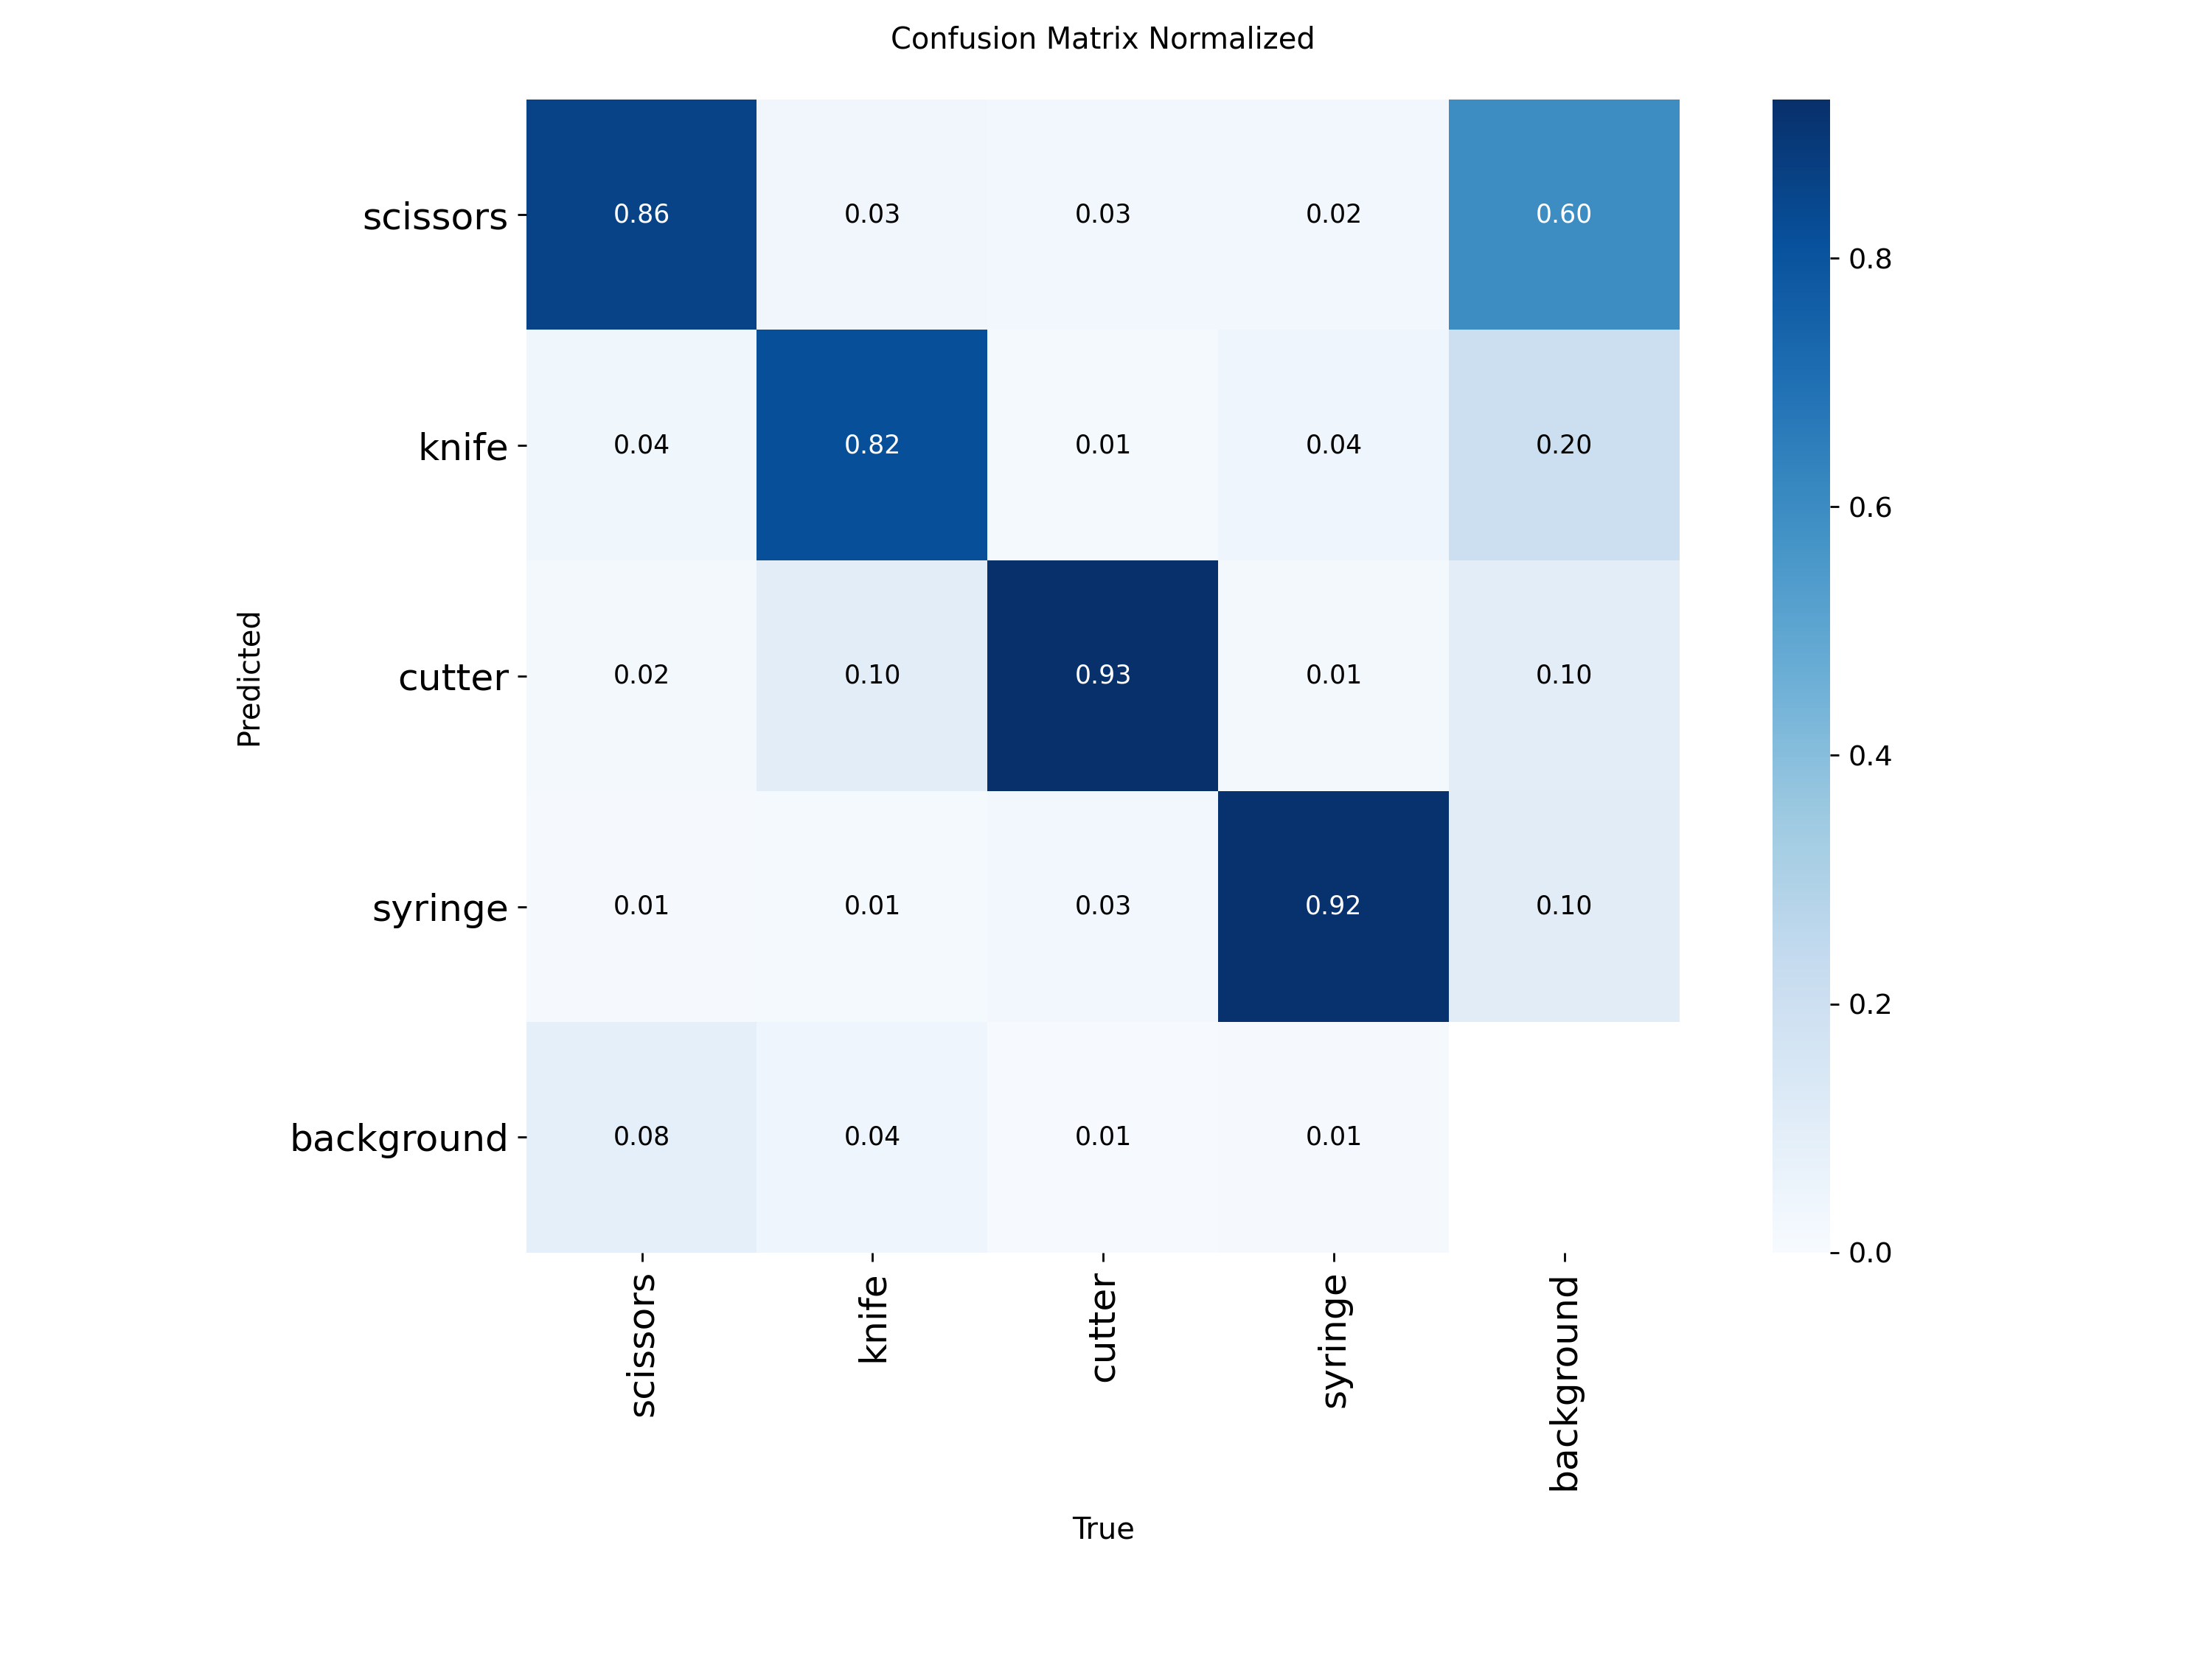

In [33]:
for filename in [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
]:
    path = RUN_DIR / filename

    if path.exists():
        print(filename)
        display(Image(filename=str(path), width=900))

<h3 style="color:#FFD866; border-left:3px solid #FFD866; padding-left:8px;">
7. 학습 모델 파일 확인
</h3>

In [ ]:
for name, model_path in (("best.pt", BEST_MODEL), ("last.pt", LAST_MODEL)):
    if not model_path.is_file():
        raise FileNotFoundError(f"Missing model artifact: {model_path}")

    print(f"{name}:", model_path)

best.pt: True /content/drive/MyDrive/AI_Project/wardy/ml/src/export/hazard_objects_v1_full_v1/weights/best.pt
last.pt: True /content/drive/MyDrive/AI_Project/wardy/ml/src/export/hazard_objects_v1_full_v1/weights/last.pt
